Anna Patronowicz 14.05.2026

# Example Dashboard

## 1. Bar chart with individial bar colors

##### This is an example how to control bar color and legend entries using color and label parameters of bar.

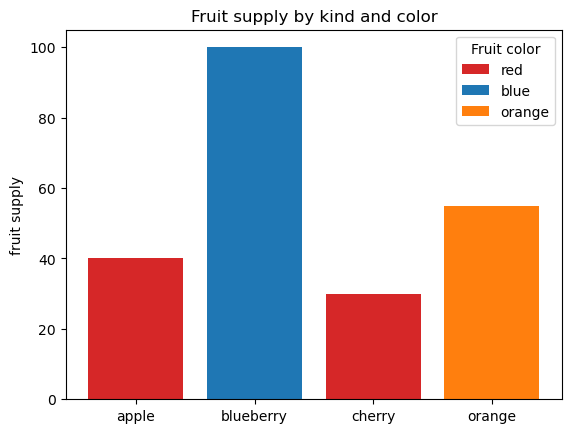

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fruits = ['apple', 'blueberry', 'cherry', 'orange']
counts = [40, 100, 30, 55]
bar_labels = ['red', 'blue', '_red', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('fruit supply')
ax.set_title('Fruit supply by kind and color')
ax.legend(title='Fruit color')

plt.show()

## 2. Lines with a ticked pateffect

##### Ticks can be added along a line to mark one side as a barrier. You can control the angle, spacing, and length of the ticks.

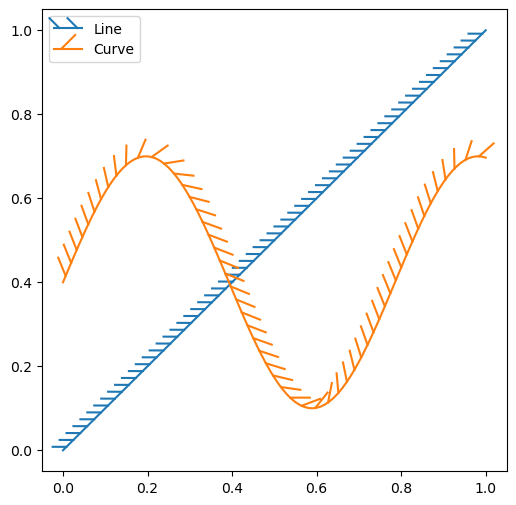

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import patheffects

# Plot a straight diagonal line with ticked style path
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], label="Line",
        path_effects=[patheffects.withTickedStroke(spacing=7, angle=135)])

# Plot a curved line with ticked style path
nx = 101
x = np.linspace(0.0, 1.0, nx)
y = 0.3*np.sin(x*8) + 0.4
ax.plot(x, y, label="Curve", path_effects=[patheffects.withTickedStroke()])

ax.legend()

plt.show()

## 3. Filled polygon

##### fill() draws a filled polygon based on lists of point coordinates x, y.

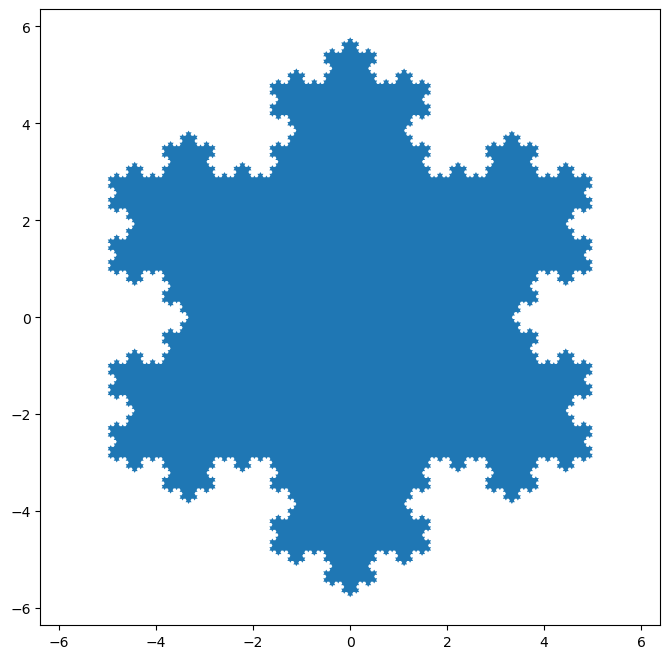

In [9]:
import matplotlib.pyplot as plt
import numpy as np


def koch_snowflake(order, scale=10):
    """
    Return two lists x, y of point coordinates of the Koch snowflake.

    Parameters
    ----------
    order : int
        The recursion depth.
    scale : float
        The extent of the snowflake (edge length of the base triangle).
    """
    def _koch_snowflake_complex(order):
        if order == 0:
            # initial triangle
            angles = np.array([0, 120, 240]) + 90
            return scale / np.sqrt(3) * np.exp(np.deg2rad(angles) * 1j)
        else:
            ZR = 0.5 - 0.5j * np.sqrt(3) / 3

            p1 = _koch_snowflake_complex(order - 1)  # start points
            p2 = np.roll(p1, shift=-1)  # end points
            dp = p2 - p1  # connection vectors

            new_points = np.empty(len(p1) * 4, dtype=np.complex128)
            new_points[::4] = p1
            new_points[1::4] = p1 + dp / 3
            new_points[2::4] = p1 + dp * ZR
            new_points[3::4] = p1 + dp / 3 * 2
            return new_points

    points = _koch_snowflake_complex(order)
    x, y = points.real, points.imag
    return x, y

x, y = koch_snowflake(order=5)

plt.figure(figsize=(8, 8))
plt.axis('equal')
plt.fill(x, y)
plt.show()